# U-Net — Carvana Image Masking

Binary semantic segmentation: predict a pixel-precise mask separating the car from the background.

**Dataset:** Carvana Image Masking Challenge — Kaggle  
**Architecture:** U-Net (Ronneberger, Fischer, Brox. MICCAI 2015. arXiv:1505.04597)  
**Loss:** BCE + Dice (`alpha=0.3`, Dice-weighted for class imbalance)  
**Resolution:** 512 x 512  
**Hardware:** Kaggle T4 GPU  

**Required datasets attached to this notebook:**
- `carvana-image-masking-challenge` (Kaggle competition dataset)
- `unet-segmentation-modules` (private dataset containing `unet.py` and `segmentation_loss.py`)

In [3]:
import sys
sys.path.append("/kaggle/input/datasets/mendelowitzadi/unet-segmentation-modules")

In [19]:
import random
from pathlib import Path
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import torch
torch.serialization.add_safe_globals([pathlib.PosixPath, pathlib.WindowsPath])

import torch.optim as optim
from PIL import Image
from torch.cuda.amp import GradScaler
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import functional as TF

from segmentation_loss import combined_loss, dice_loss
from unet import UNet

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
CONFIG = {
    "data_root":    Path("/kaggle/input/carvana-image-masking-challenge"),
    "img_dir":  Path("/kaggle/input/datasets/ipythonx/carvana-image-masking-png/train_images"),
    "mask_dir": Path("/kaggle/input/datasets/ipythonx/carvana-image-masking-png/train_masks"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "img_size":     512,
    "in_channels":  3,
    "num_classes":  1,
    "batch_size":   8,
    "epochs":       20,
    "lr":           1e-4,
    "val_fraction": 0.1,
    "alpha":        0.3,   # BCE weight; 1-alpha=0.7 goes to Dice
    "seed":         42,
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
torch.cuda.manual_seed_all(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [6]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class CarvanaDataset(Dataset):
    """Carvana Image Masking dataset.

    Images are JPEG, masks are GIF (binary: 0 background, 255 car).
    Masks are normalised to {0, 1} before returning.

    Augmentation is applied identically to image and mask using
    torchvision.transforms.functional with a shared random state,
    so spatial transforms stay in sync. Mask interpolation uses
    nearest-neighbour to preserve binary values.

    Args:
        img_dir:   Directory containing .jpg images.
        mask_dir:  Directory containing _mask.gif files.
        img_size:  Both height and width are resized to this value.
        augment:   If True, apply random flip and rotation.
    """

    # ImageNet statistics used because the encoder was conceptually
    # designed for natural images and these stats are standard practice.
    MEAN = (0.485, 0.456, 0.406)
    STD  = (0.229, 0.224, 0.225)

    def __init__(self, img_dir: Path, mask_dir: Path, img_size: int, augment: bool) -> None:
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment  = augment
        self.ids      = sorted(p.stem for p in img_dir.glob("*.jpg"))

        if not self.ids:
            raise FileNotFoundError(f"No .jpg images found in {img_dir}")

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]
        img  = Image.open(self.img_dir  / f"{stem}.jpg").convert("RGB")
        mask = Image.open(self.mask_dir / f"{stem}.png").convert("L")

        img, mask = self._resize(img, mask)
        if self.augment:
            img, mask = self._augment(img, mask)

        img  = TF.to_tensor(img)          # (3, H, W), float32 in [0, 1]
        img  = TF.normalize(img, self.MEAN, self.STD)
        mask = torch.from_numpy(np.array(mask)).unsqueeze(0).float()  # preserves 0/1 values
        return img, mask

    def _resize(self, img: Image.Image, mask: Image.Image):
        size = (self.img_size, self.img_size)
        img  = TF.resize(img,  size, interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, size, interpolation=TF.InterpolationMode.NEAREST)
        return img, mask

    def _augment(self, img: Image.Image, mask: Image.Image):
        if random.random() > 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            img   = TF.rotate(img,  angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask  = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

        return img, mask

In [7]:
# ── Data loaders ──────────────────────────────────────────────────────────────
full_dataset = CarvanaDataset(
    img_dir=CONFIG["img_dir"],
    mask_dir=CONFIG["mask_dir"],
    img_size=CONFIG["img_size"],
    augment=False,  # overridden per split below
)

n_total = len(full_dataset)
n_val   = max(1, int(n_total * CONFIG["val_fraction"]))
n_train = n_total - n_val

# Split on indices; augmentation is set at construction time so we build
# two separate dataset objects sharing the same file list split.
all_ids = full_dataset.ids
rng     = torch.Generator().manual_seed(CONFIG["seed"])
indices = torch.randperm(n_total, generator=rng).tolist()
train_ids = [all_ids[i] for i in indices[:n_train]]
val_ids   = [all_ids[i] for i in indices[n_train:]]


class _SubsetDataset(CarvanaDataset):
    """CarvanaDataset restricted to a pre-selected list of IDs."""
    def __init__(self, ids, **kwargs):
        super().__init__(**kwargs)
        self.ids = ids


train_dataset = _SubsetDataset(
    ids=train_ids,
    img_dir=CONFIG["img_dir"],
    mask_dir=CONFIG["mask_dir"],
    img_size=CONFIG["img_size"],
    augment=True,
)
val_dataset = _SubsetDataset(
    ids=val_ids,
    img_dir=CONFIG["img_dir"],
    mask_dir=CONFIG["mask_dir"],
    img_size=CONFIG["img_size"],
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Train samples: {len(train_dataset):,}  |  Val samples: {len(val_dataset):,}")

Train samples: 4,580  |  Val samples: 508


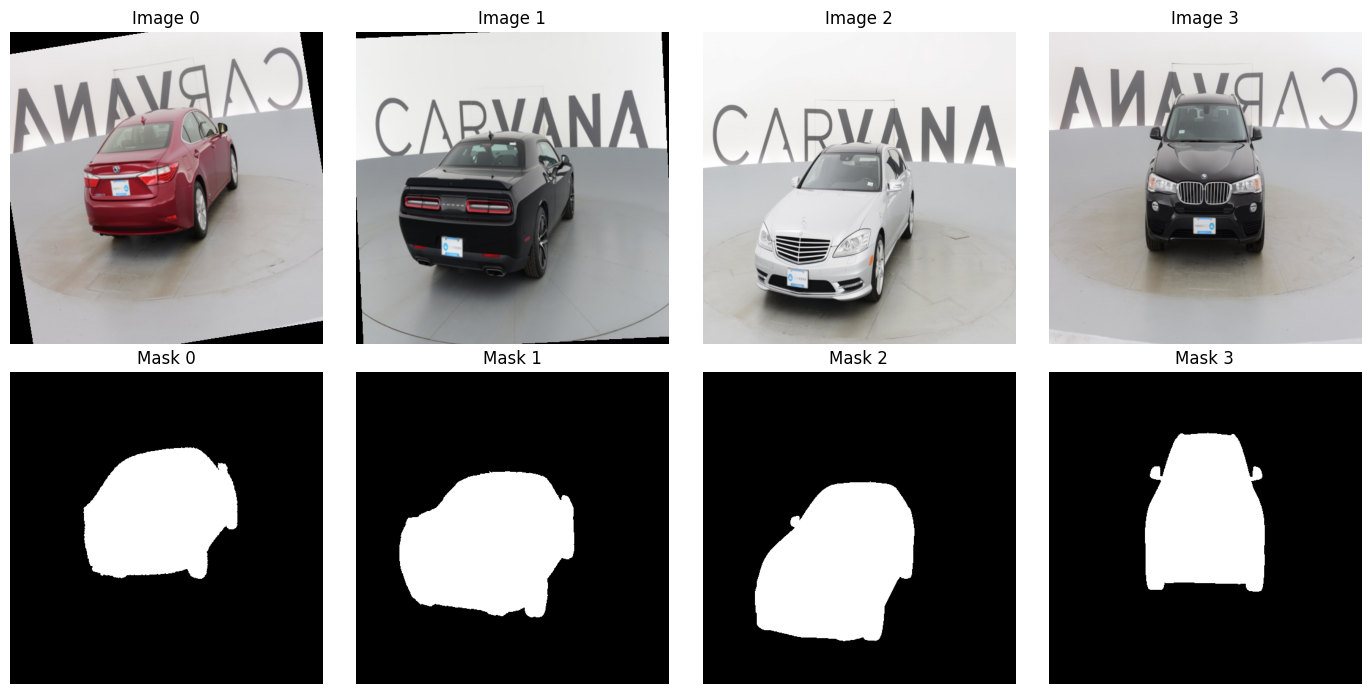

Image shape: torch.Size([8, 3, 512, 512])  |  Mask shape: torch.Size([8, 1, 512, 512])
Mask unique values: [0.0, 1.0]


In [8]:
# ── Sanity-check one batch visually ───────────────────────────────────────────
MEAN_T = torch.tensor(CarvanaDataset.MEAN).view(3, 1, 1)
STD_T  = torch.tensor(CarvanaDataset.STD).view(3, 1, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img_display = (imgs[i] * STD_T + MEAN_T).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, i].imshow(img_display)
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")
    axes[1, i].imshow(masks[i].squeeze(), cmap="gray")
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/sample_batch.png", dpi=100)
plt.show()
print(f"Image shape: {imgs.shape}  |  Mask shape: {masks.shape}")
print(f"Mask unique values: {masks.unique().tolist()}")

In [9]:
# ── Model, optimiser, scheduler ───────────────────────────────────────────────
model = UNet(in_channels=CONFIG["in_channels"], num_classes=CONFIG["num_classes"]).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG["lr"],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG["epochs"],
)
scaler = GradScaler()

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 28,948,673


/tmp/ipykernel_55/513948476.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [13]:
# ── Train / val loops ─────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, alpha):
    model.train()
    total_loss = 0.0

    for imgs, masks in loader:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss   = combined_loss(logits, masks, alpha=alpha)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device, alpha):
    model.eval()
    total_loss  = 0.0
    total_dice  = 0.0

    for imgs, masks in loader:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss   = combined_loss(logits, masks, alpha=alpha)

        probs = torch.sigmoid(logits.float())   # cast out of fp16 for metrics
        dice  = 1.0 - dice_loss(probs, masks.float())

        total_loss += loss.item()
        total_dice += dice.item()

    n = len(loader)
    return total_loss / n, total_dice / n

In [20]:
# ── Training ──────────────────────────────────────────────────────────────────
checkpoint_path = CONFIG["checkpoint_dir"] / "best_unet_carvana.pth"

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    print(
        f"Checkpoint found -- skipping training.\n"
        f"Loaded: epoch={checkpoint['epoch']}  "
        f"val_loss={checkpoint['val_loss']:.4f}  "
        f"val_dice={checkpoint['val_dice']:.4f}"
    )
    history = {"train_loss": [], "val_loss": [], "val_dice": []}

else:
    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    best_val_loss = float("inf")
    
    for epoch in range(1, CONFIG["epochs"] + 1):
        train_loss             = train_one_epoch(
            model, train_loader, optimizer, scheduler, scaler, DEVICE, CONFIG["alpha"]
        )
        val_loss, val_dice     = evaluate(model, val_loader, DEVICE, CONFIG["alpha"])
    
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
    
        print(
            f"Epoch {epoch:02d}/{CONFIG['epochs']}  "
            f"train_loss={train_loss:.4f}  "
            f"val_loss={val_loss:.4f}  "
            f"val_dice={val_dice:.4f}"
        )
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "epoch":      epoch,
                    "model":      model.state_dict(),
                    "optimizer":  optimizer.state_dict(),
                    "val_loss":   val_loss,
                    "val_dice":   val_dice,
                    "config":     CONFIG,
                },
                CONFIG["checkpoint_dir"] / "best_unet_carvana.pth",
            )
            print(f"  -> Saved best checkpoint (val_loss={val_loss:.4f})")

Checkpoint found -- skipping training.
Loaded: epoch=20  val_loss=0.0045  val_dice=0.9955


In [22]:
# ── Training curves ───────────────────────────────────────────────────────────
if history["train_loss"]:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="Train loss")
    ax1.plot(epochs, history["val_loss"],   label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Combined loss (BCE + Dice)")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history["val_dice"], color="green", label="Val Dice")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Dice score")
    ax2.set_title("Validation Dice score")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
else:
    print("Training was skipped -- curves not available.")

Training was skipped -- curves not available.


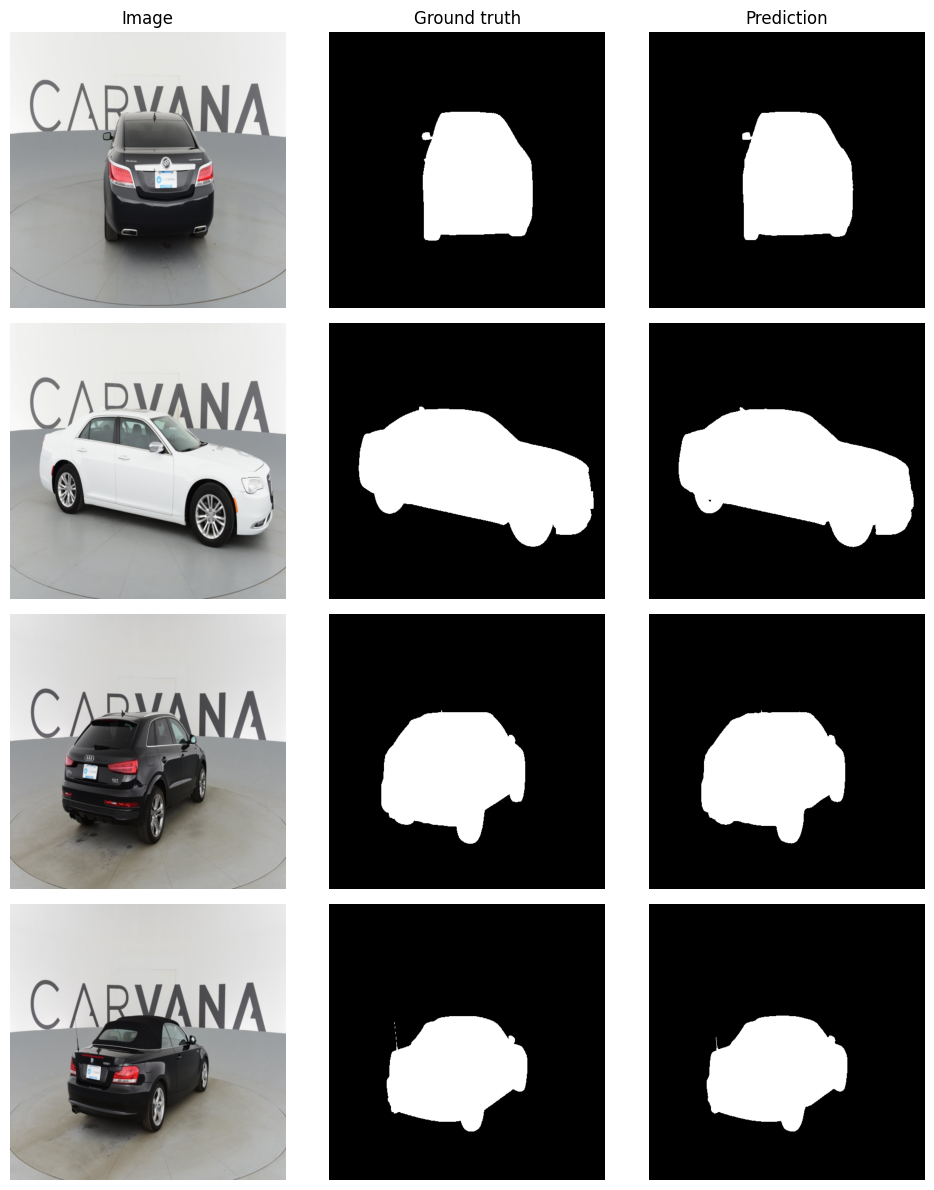

Best checkpoint: epoch=20  val_loss=0.0045  val_dice=0.9955


In [23]:
# ── Qualitative predictions on val samples ────────────────────────────────────
checkpoint = torch.load(
    CONFIG["checkpoint_dir"] / "best_unet_carvana.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(checkpoint["model"])
model.eval()

imgs, masks = next(iter(val_loader))
imgs  = imgs.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs).float())
    preds_binary = (preds > 0.5).float()

n_show = min(4, imgs.size(0))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))
titles = ["Image", "Ground truth", "Prediction"]
for col, title in enumerate(titles):
    axes[0, col].set_title(title)

for i in range(n_show):
    img_display = (
        (imgs[i].cpu() * torch.tensor(CarvanaDataset.STD).view(3, 1, 1)
         + torch.tensor(CarvanaDataset.MEAN).view(3, 1, 1))
        .permute(1, 2, 0).clamp(0, 1).numpy()
    )
    axes[i, 0].imshow(img_display)
    axes[i, 1].imshow(masks[i].cpu().squeeze(), cmap="gray")
    axes[i, 2].imshow(preds_binary[i].cpu().squeeze(), cmap="gray")
    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/predictions.png", dpi=150)
plt.show()

print(f"Best checkpoint: epoch={checkpoint['epoch']}  "
      f"val_loss={checkpoint['val_loss']:.4f}  "
      f"val_dice={checkpoint['val_dice']:.4f}")